# Business Problem

Shopping malls collect customer information such as age, annual income, and spending behavior. However, treating all customers as a single group can lead to ineffective marketing strategies.

The objective of this project is to segment customers into distinct groups using unsupervised machine learning techniques. By identifying customers with similar characteristics, businesses can design targeted marketing campaigns, improve customer retention, and optimize resource allocation.

The project applies K-Means clustering to discover natural customer segments based on spending patterns and income levels.

In [144]:
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
pd.set_option('display.max_columns', None)

In [145]:
df = pd.read_csv('../data/raw/mall_customers.csv')

In [146]:
df.shape

(200, 5)

In [147]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')

In [148]:
df.dtypes

CustomerID                int64
Gender                      str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

In [149]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [150]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [151]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [152]:
df.describe(include='string')

,Gender
count,200
unique,2
top,Female
freq,112


In [153]:
df.duplicated().sum()

np.int64(0)

In [154]:
df.isna().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [155]:
df.dtypes

CustomerID                int64
Gender                      str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

# Data Preparation

The dataset was examined for missing values, duplicate records, and data inconsistencies. Since the data was already clean, minimal preprocessing was required.

Feature scaling was performed before clustering because K-Means relies on distance calculations. Standardization ensures that all features contribute equally to cluster formation and prevents variables with larger scales from dominating the clustering process.

In [156]:
gender_mapping = {
    'Male': 0,
    'Female': 1
}

df['Gender'] = df['Gender'].map(gender_mapping)

In [157]:
scaled_df = pd.DataFrame(
    StandardScaler().fit_transform(df.drop(columns=['CustomerID'])),
    columns=df.drop(columns=['CustomerID']).columns,
    index=df.index
)

In [158]:
scaled_df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,-1.128152,-1.424569,-1.738999,-0.434801
1,-1.128152,-1.281035,-1.738999,1.195704
2,0.886405,-1.352802,-1.700830,-1.715913
3,0.886405,-1.137502,-1.700830,1.040418
4,0.886405,-0.563369,-1.662660,-0.395980


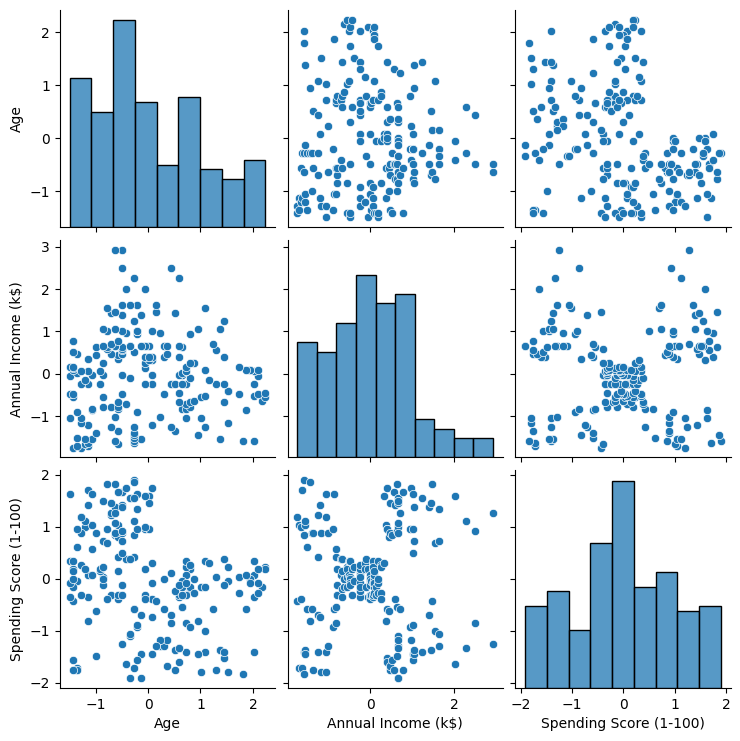

In [159]:
sns.pairplot(scaled_df.drop(columns=['Gender']))

In [160]:
def analyze_clusters(df, features, max_k=10):
    """
    Analyze clustering performance for selected features.

    Parameters:
    -----------
    df : pandas.DataFrame
    features : list
        List of column names to use
    max_k : int
        Maximum number of clusters to test
    """

    # Select features
    X = df[features]

    inertias = []
    silhouette_scores = []

    k_range = range(2, max_k + 1)

    for k in k_range:

        kmeans = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=10
        )

        labels = kmeans.fit_predict(X)

        inertias.append(kmeans.inertia_)

        silhouette_scores.append(
            silhouette_score(X, labels)
        )

    # Plot Elbow Curve
    plt.figure(figsize=(8,5))
    plt.plot(k_range, inertias, marker='o')
    plt.xlabel("Number of Clusters (K)")
    plt.ylabel("Inertia (WCSS)")
    plt.title(f"Elbow Curve: {features}")
    plt.show()

    # Plot Silhouette Scores
    plt.figure(figsize=(8,5))
    plt.plot(k_range, silhouette_scores, marker='o')
    plt.xlabel("Number of Clusters (K)")
    plt.ylabel("Silhouette Score")
    plt.title(f"Silhouette Analysis: {features}")
    plt.show()

    best_k = k_range[
        silhouette_scores.index(max(silhouette_scores))
    ]

    print(f"Best K according to silhouette score: {best_k}")
    print(f"Best silhouette score: {max(silhouette_scores):.4f}")

    return X, best_k

In [161]:
def statistical_summary_by_cluster(df, features, n_clusters):
    """
    Generate statistical summary of clusters.

    Parameters:
    -----------
    df : pandas.DataFrame
    features : list
        List of column names to use
    n_clusters : int
        Number of clusters to form
    """

    # Select features
    X = df[features]

    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=42,
        n_init=10
    )

    df['Cluster'] = kmeans.fit_predict(X)

    summary = df.groupby('Cluster')[features].agg(['mean', 'std', 'min', 'max', 'count'])
    
    print(summary)

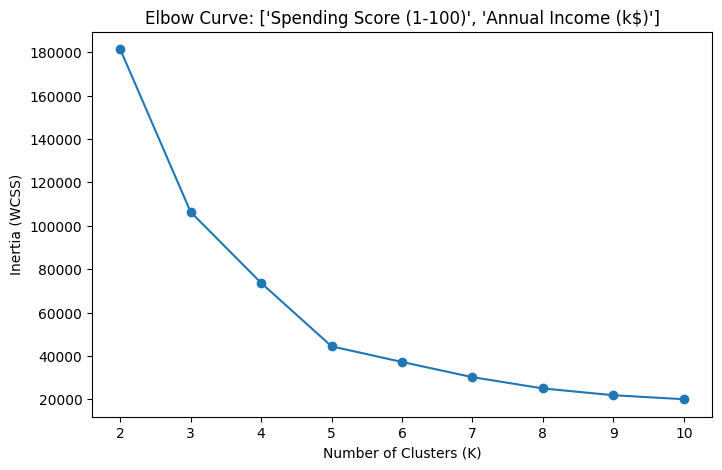

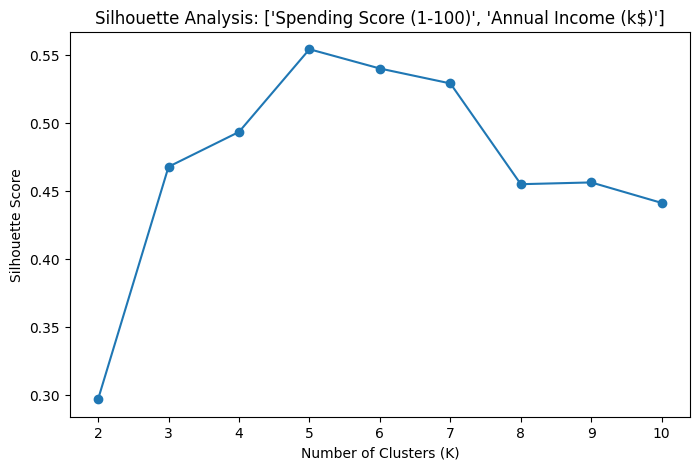

Best K according to silhouette score: 5
Best silhouette score: 0.5539


(     Spending Score (1-100)  Annual Income (k$)
 0                        39                  15
 1                        81                  15
 2                         6                  16
 3                        77                  16
 4                        40                  17
 ..                      ...                 ...
 195                      79                 120
 196                      28                 126
 197                      74                 126
 198                      18                 137
 199                      83                 137
 
 [200 rows x 2 columns],
 5)

In [162]:
analyze_clusters(df, features=['Spending Score (1-100)', 'Annual Income (k$)'])

In [163]:
statistical_summary_by_cluster(df, features=['Spending Score (1-100)', 'Annual Income (k$)'], n_clusters=5)

        Spending Score (1-100)                          Annual Income (k$)  \
                          mean        std min max count               mean   
Cluster                                                                      
0                    49.518519   6.530909  34  61    81          55.296296   
1                    82.128205   9.364489  63  97    39          86.538462   
2                    79.363636  10.504174  61  99    22          25.727273   
3                    17.114286   9.952154   1  39    35          88.200000   
4                    20.913043  13.017167   3  40    23          26.304348   

                                   
               std min  max count  
Cluster                            
0         8.988109  39   76    81  
1        16.312485  69  137    39  
2         7.566731  15   39    22  
3        16.399067  70  137    35  
4         7.893811  15   39    23  


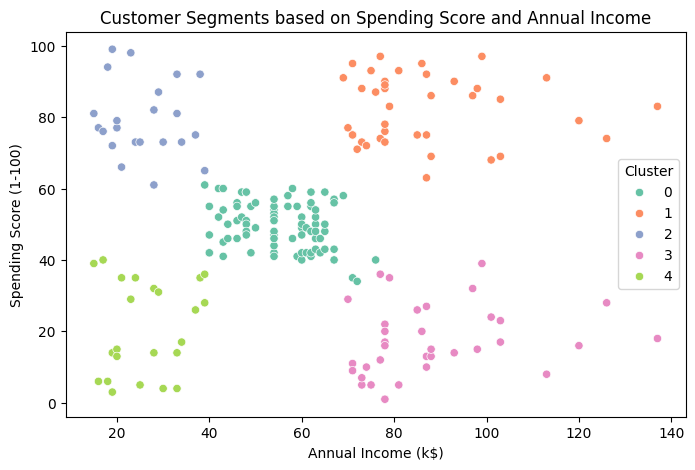

In [164]:
# Plottinhg clusters in original feature space
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(df[['Spending Score (1-100)', 'Annual Income (k$)']])
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set2'
)
plt.title("Customer Segments based on Spending Score and Annual Income")
plt.show()

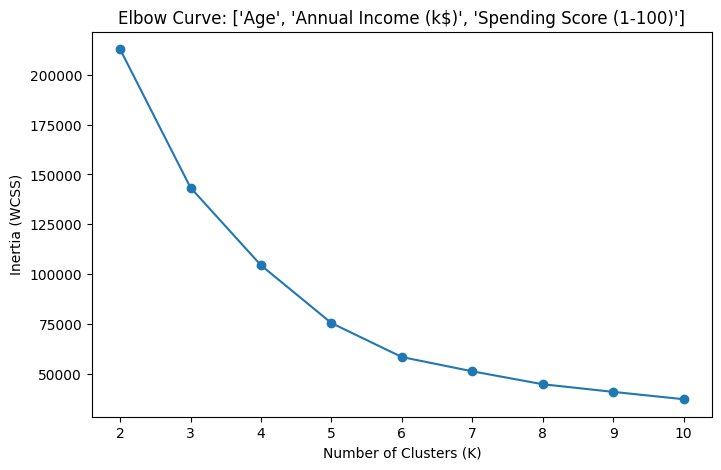

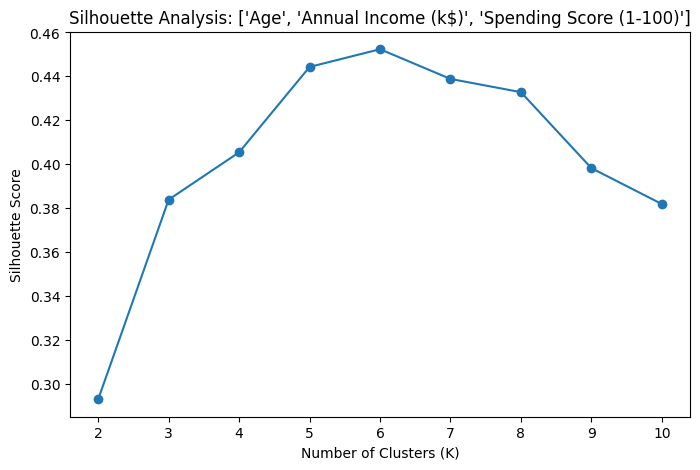

Best K according to silhouette score: 6
Best silhouette score: 0.4523


(     Age  Annual Income (k$)  Spending Score (1-100)
 0     19                  15                      39
 1     21                  15                      81
 2     20                  16                       6
 3     23                  16                      77
 4     31                  17                      40
 ..   ...                 ...                     ...
 195   35                 120                      79
 196   45                 126                      28
 197   32                 126                      74
 198   32                 137                      18
 199   30                 137                      83
 
 [200 rows x 3 columns],
 6)

In [165]:
analyze_clusters(df, features=['Age', 'Annual Income (k$)', 'Spending Score (1-100)'])

In [166]:
statistical_summary_by_cluster(df, features=['Spending Score (1-100)', 'Annual Income (k$)', 'Age'], n_clusters=5)

        Spending Score (1-100)                          Annual Income (k$)  \
                          mean        std min max count               mean   
Cluster                                                                      
0                    20.913043  13.017167   3  40    23          26.304348   
1                    49.569620   6.242295  35  60    79          55.291139   
2                    82.128205   9.364489  63  97    39          86.538462   
3                    17.583333  10.204691   1  39    36          87.750000   
4                    78.565217  10.953729  61  99    23          26.304348   

                                         Age                           
               std min  max count       mean        std min max count  
Cluster                                                                
0         7.893811  15   39    23  45.217391  13.228607  19  67    23  
1         8.710665  40   76    79  43.088608  16.478572  18  70    79  
2        16.312

# Cluster Interpretation

The customer segmentation analysis identified five distinct customer groups based on Age, Annual Income, and Spending Score. These segments reveal meaningful differences in purchasing behavior and demographic characteristics.

### Cluster 0: Middle-Aged Low-Spending Customers
- Average Age: 45 years
- Average Income: \$26k
- Average Spending Score: 21

Customers in this segment have relatively low incomes and low spending behavior. They represent a budget-conscious customer group and may respond well to discounts and promotional offers.

### Cluster 1: Average Customers
- Average Age: 43 years
- Average Income: \$55k
- Average Spending Score: 50

This is the largest cluster and represents customers with moderate income and average spending habits. These customers form the core customer base of the mall.

### Cluster 2: Young High-Value Customers
- Average Age: 33 years
- Average Income: \$87k
- Average Spending Score: 82

This segment consists of younger customers with high incomes and high spending scores. They are the most valuable customer group and are ideal targets for premium products, loyalty programs, and personalized marketing campaigns.

### Cluster 3: High-Income Low-Spending Customers
- Average Age: 41 years
- Average Income: \$88k
- Average Spending Score: 18

Despite having high purchasing power, these customers spend relatively little. This group represents a potential growth opportunity, as targeted marketing strategies may encourage higher engagement and spending.

### Cluster 4: Young Enthusiastic Shoppers
- Average Age: 26 years
- Average Income: \$26k
- Average Spending Score: 79

These customers have lower incomes but exhibit strong spending behavior. Their purchasing habits suggest a high level of engagement with mall products and services despite limited earning capacity.

### Business Insights

The analysis highlights two particularly important customer segments:

1. **Young High-Value Customers (Cluster 2)** represent the most profitable segment due to their combination of high income and high spending behavior.

2. **High-Income Low-Spending Customers (Cluster 3)** represent an untapped opportunity where targeted promotions and loyalty programs may increase spending.

Customer segmentation enables businesses to tailor marketing strategies to specific customer groups, improving customer satisfaction and maximizing revenue.

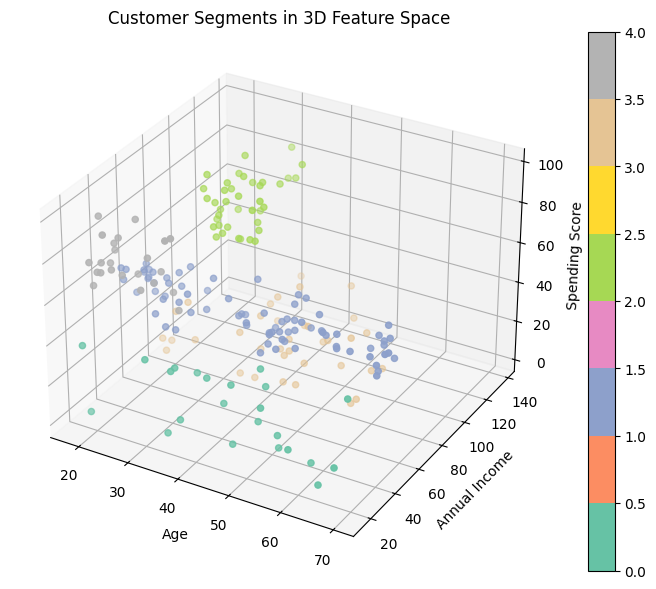

In [167]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(
    df[['Age',
        'Annual Income (k$)',
        'Spending Score (1-100)']]
)

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df['Age'],
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster'],
    cmap='Set2'
)

ax.set_xlabel('Age')
ax.set_ylabel('Annual Income')
ax.set_zlabel('Spending Score')

ax.set_title('Customer Segments in 3D Feature Space')

plt.colorbar(scatter)
plt.show()

<Axes: >

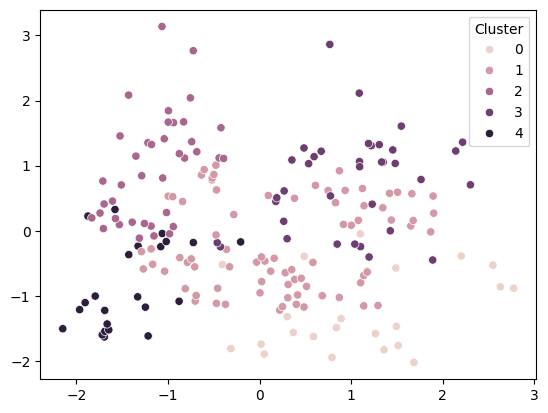

In [168]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(scaled_df)

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=df['Cluster']
)

# PCA-Based Cluster Visualization

Principal Component Analysis (PCA) was applied to reduce the dimensionality of the dataset and visualize customer clusters in a two-dimensional space.

Although some overlap between clusters is visible, distinct customer groups can still be observed. The overlap is expected because PCA compresses information from multiple dimensions into only two principal components.

The visualization supports the clustering structure identified by K-Means while providing an intuitive representation of customer segmentation.

In [169]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# Fit DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(scaled_df)

# Number of clusters (excluding noise)
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)

print(f"Number of clusters: {n_clusters}")
print(f"Noise points: {list(dbscan_labels).count(-1)}")

# Silhouette score can only be calculated if >1 cluster exists
if n_clusters > 1:
    score = silhouette_score(scaled_df, dbscan_labels)
    print(f"DBSCAN Silhouette Score: {score:.4f}")
else:
    print("Silhouette score cannot be computed.")

Number of clusters: 9
Noise points: 105
DBSCAN Silhouette Score: 0.0120


<Axes: xlabel='Cluster'>

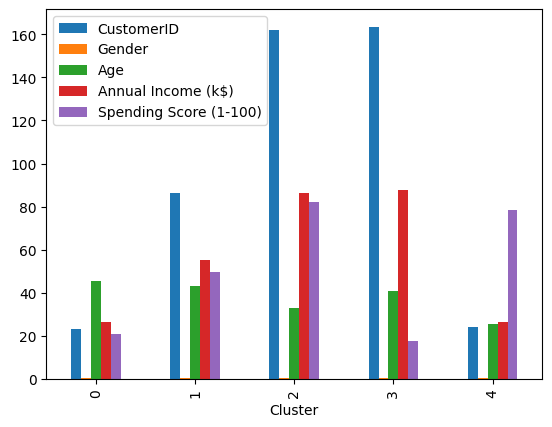

In [170]:
cluster_profile = df.groupby('Cluster').mean()
cluster_profile.plot(kind='bar')

In [171]:
df.to_csv('../data/processed/mall_customers_with_clusters.csv', index=False)

# Conclusion

Customer segmentation was performed using K-Means clustering on the Mall Customers dataset.

Several values of K were evaluated using the Elbow Method and Silhouette Score, with five clusters providing the best balance between cluster compactness and separation.

Two feature combinations were explored:

- Annual Income and Spending Score
- Age, Annual Income, and Spending Score

The two-feature model achieved a higher silhouette score (55.39%) compared to the three-feature model (approximately 44%), indicating better cluster separation but there is a tradeoff between the amount of information and teh better clustering, due to the business needs as age is an important factor we chose Age, Spending Score and Annual Income to be the basis of our cluster using K means as DBSCAN performed poorly

PCA visualization further confirmed the presence of meaningful customer segments. These segments can help businesses identify high-value customers, develop targeted marketing strategies, and improve customer engagement.

Overall, K-Means proved to be an effective technique for uncovering customer groups within the dataset.